# Ten-year multi-image light curves and survey observations

The intrinsic driver belongs to the shared source. This example uses a Q2237-like `KerrDiskModel` in all six Rubin bands, with the driver heating an axial lamppost and producing a wavelength-dependent delayed thermal response. Pass only the source to `MultiImageSystem`. Sources without drivers also work, and explicit `apply_driving_signal=True` requires an attached driver.


Each macroimage has an independent moving star field, local macro model, and
arrival delay, while all images share one stochastic intrinsic driver. Maps
are generated every 25 days and the source is evaluated daily for ten years.
At each daily epoch the code interpolates the two bracketing map--source
contractions, retaining at most two maps instead of constructing daily maps.
Physical Jy fluxes use the AB zero point, so both truth curves and noisy observations
are shown in magnitudes.

The notebook requires a Rubin OpSim SQLite database, found through
`MICROCAUSTICS_LSST_OPSIM` or by searching parent directories for
`baseline_v4.3.5_10yrs.db`. It builds a reusable `RubinOpSimCadenceIndex`,
selects a reproducible random Wide-Fast-Deep (WFD) field with `rubin.sample`,
and applies the same six-band visit sequence to both macroimages.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())



Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
lens_redshift, source_redshift = 0.0395, 1.695
source_resolution = 1024 if use_cuda else 256
bands = {
    "u": 3671.0, "g": 4827.0, "r": 6223.0,
    "i": 7546.0, "z": 8691.0, "y": 9712.0,
}
driver = mc.broken_power_law_driving_signal(
    cadence_days=1.0,
    break_timescale_days=200.0,
    alpha_L=1.0,
    alpha_R=3.0,
    standard_deviation=0.10,
    seed=0,
)
source = mc.KerrDiskModel(
    black_hole_mass_solar=10.0**9.08,
    eddington_ratio=0.34,
    bands_angstrom=bands,
    spin=0.74,
    inclination_deg=10.0,
    position_angle_deg=0.0,
    source_redshift=source_redshift,
    lamp_fraction=0.1,
    corona_height_above_isco_rg=20.0,
    driving_signal=driver,
    source_grid_shape=source_resolution,
    enclosed_flux_fraction=0.999,
    source_margin=1.05,
    compile_solver=use_cuda,
)

population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=340.126125, dec_deg=3.358611,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
)

# One shared physical prescription is expanded into independent seeded star
# fields for the two macroimages. Scalars can be replaced by per-image
# mappings whenever the observed images require different assumptions.
system = mc.MultiImageSystem(
    lens_redshift=lens_redshift,
    source_redshift=source_redshift,
    images={
        "A": mc.MacroLens(convergence=0.396, shear=0.396, shear_angle_deg=175.0),
        "B": mc.MacroLens(convergence=0.391, shear=0.391, shear_angle_deg=141.73),
    },
    source=source,
    stellar_population=population,
    integration_domain="scout",
    duration_days=3650.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed={"A": 0, "B": 1},
    arrival_time_delays_days={"A": 0.0, "B": 8.0},
    methods=method,
    runtime=runtime_config,
    caustic_grid_shape=256,
)


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\primary.py:223: CompilationWarning: Compilation event 1: preparing a new torch.compile specialization for primary Kerr ray tracing on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  calculation, execution = _primary_calculation(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\coordinates.py:1158: CompilationWarning: Compilation event 2: preparing a new torch.compile specialization for Kerr observer coordinates on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  solver, execution = _coordinate_solver(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\relativity\lamppost.py:625: CompilationWarning: Compilation event 3: preparing a new torch.compile specialization for axis-lamppost ray tracing on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  rays = trace_axis_lamppost(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\lens\models.py:842: CompilationWarning: Compilation event 4: preparing a new torch.compile specialization for specular stellar-boundary evolution on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  positions, _ = run_tensor_kernel(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:902: CompilationWarning: Compilation event 5: preparing a new Triton specialization for IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(
C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\solvers\ipm.py:1291: CompilationWarning: Compilation event 6: preparing a new Triton specialization for batched IPM rasterization on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  _warn_new_triton_ipm_specialization(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\sources\reprocessing.py:553: CompilationWarning: Compilation event 7: preparing a new torch.compile specialization for retarded thermal driving on cuda (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  temperature4, _ = run_tensor_kernel(


C:\Users\fagin\Desktop\microlensing\microcaustics_package\src\microcaustics\sources\transferred_disk.py:209: CompilationWarning: Compilation event 8: preparing a new Triton specialization for thermal spectral photometry on cuda:0 (torch.float32). This first call may be slow while code is compiled or loaded from the compiler cache. Another warning for this component indicates a new specialization or cache miss. Set warn_on_compile=False to suppress these messages.
  fast_result = triton_thermal_flux(left, right, fraction, arguments, runtime)


(<Figure size 640x380 with 1 Axes>,
 <Axes: title={'center': 'Image A: six-band daily truth'}, xlabel='Time [days]', ylabel='brightness [mag]'>)

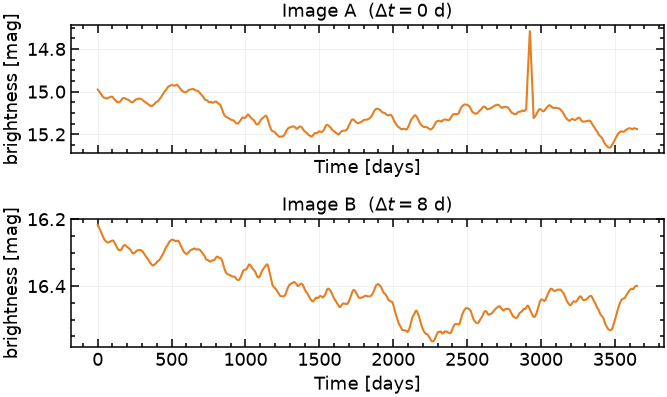

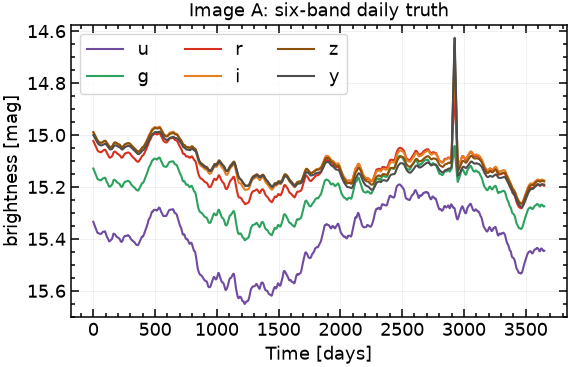

In [3]:
curves = system.light_curves(
    duration_days=3650, map_cadence_days=25, source_cadence_days=1,
    temporal_batch_size=49, scout_refresh_frames=10,
)
mcp.plot_multi_image_light_curves(
    curves,
    band="i",
    magnitude=True,
    normalize=False,
)
mcp.plot_light_curve(
    curves.images[0].light_curve,
    bands=tuple(bands),
    magnitude=True,
    normalize=False,
    title="Image A: six-band daily truth",
)


Using Rubin OpSim database: C:\Users\fagin\Desktop\microlensing\baseline_v4.3.5_10yrs.db
Seeded WFD selection: {'survey': 'Rubin WFD', 'selection': 'random_wfd', 'field_ra_deg': 185.1568603515625, 'field_dec_deg': -43.61547088623047, 'selection_radius_deg': 1.75, 'source_visit_index': 1724561, 'seed': 2026, 'database': 'baseline_v4.3.5_10yrs.db', 'survey_start_mjd': 60980.00158187724, 'selected_bands': ('g', 'i', 'r', 'u', 'y', 'z'), 'parent_visit_count': 831}
Visits by band: {'u': 54, 'g': 64, 'r': 193, 'i': 190, 'z': 172, 'y': 158}


(<Figure size 640x380 with 1 Axes>,
 <Axes: title={'center': 'Observed image A'}, xlabel='Time [days]', ylabel='brightness [mag]'>)

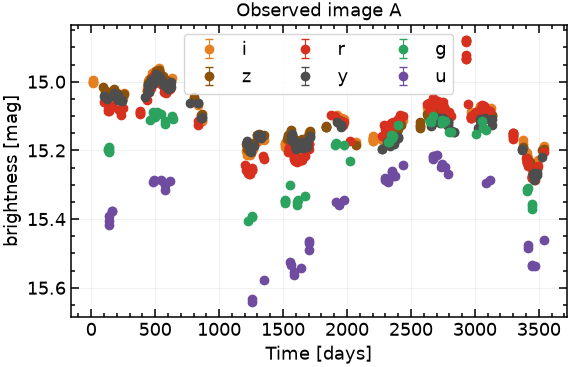

In [4]:
opsim_path = mc.find_rubin_opsim_database()
if opsim_path is None:
    raise FileNotFoundError(
        "Set MICROCAUSTICS_LSST_OPSIM to a Rubin OpSim SQLite database "
        "or place baseline_v4.3.5_10yrs.db in a parent directory."
    )
wfd_seed = 2026
rubin = mc.RubinOpSimCadenceIndex.from_database(opsim_path)
cadence = rubin.sample(
    seed=wfd_seed,
    survey="wfd",
    duration_days=3650.0,
).select_bands(tuple(bands))
assert set(cadence.band_names) == set(bands)
visit_counts = {name: cadence.band_names.count(name) for name in bands}
print("Using Rubin OpSim database:", opsim_path)
print("Seeded WFD selection:", cadence.metadata)
print("Visits by band:", visit_counts)
observations = mc.observe_multi_image_light_curves(
    curves,
    cadence,
    seed=0,
)
mcp.plot_photometric_observations(
    observations,
    image="A",
    marker_size=6.0,
    capsize=3.0,
)